In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
import utils

TRANSFERS_FILE = "data/erc1155_transfers.parquet"
RANKING_FILE = "results/ranking.tsv"
GRAPH_CENTRALIZATION_FILE = 'results/graph_centralization.tsv'
GRAPH_STATS_FILE="results/graph_stats.tsv"

In [2]:
cdf = pl.read_csv(GRAPH_CENTRALIZATION_FILE, separator='\t')
rdf = pl.read_csv(RANKING_FILE, separator='\t')
df = rdf.join(cdf, on='address', how='left').select('contract_id', 'address', 'num_transfer', 'num_nodes', 'num_edges', 'in_cent', 'out_cent')
df

contract_id,address,num_transfer,num_nodes,num_edges,in_cent,out_cent
i64,str,i64,i64,i64,f64,f64
0,"""0x495f947276749ce646f68ac8c248…",3898575,938630,2261588,0.0131656,0.004122
1,"""0x76be3b62873462d2142405439777…",1237657,81542,329122,0.0195605,0.303016
2,"""0xc36cf0cfcb5d905b8b513860db0c…",939823,102458,322871,0.0904666,0.619806
3,"""0xfaafdc07907ff5120a76b34b731b…",691886,90830,262459,0.0158994,0.271459
4,"""0xa342f5d851e866e18ff98f351f2c…",440927,161557,248259,0.003042,0.197446
…,…,…,…,…,…,…
38776,"""0x097c6b2996362d9cd24cbaccb716…",1,2,1,1.0,1.0
38777,"""0x8b393a52e353a6fab6b3b234a6b9…",1,2,1,1.0,1.0
38778,"""0x450e3cb2100e56720e3ebf05c77e…",1,2,1,1.0,1.0


In [3]:
in_stars = df.filter((pl.col("in_cent") == 1) & (pl.col("out_cent") != 1))
out_stars = df.filter((pl.col("in_cent") != 1) & (pl.col("out_cent") == 1))
in_out_stars = df.filter((pl.col("in_cent") == 1) & (pl.col("out_cent") == 1))
not_stars = df.filter((pl.col("in_cent") != 1) & (pl.col("out_cent") != 1))
print(f'There are {len(in_stars)} stars w.r.t. in-degree (i.e., {len(in_stars)*100/len(df)}% of the total).')
print(f'There are {len(out_stars)} stars w.r.t. out-degree (i.e., {len(out_stars)*100/len(df)}% of the total).')
print(f'There are {len(in_out_stars)} stars w.r.t. both in- and out-degree (i.e., {len(in_out_stars)*100/len(df)}% of the total).')
print(f'There are {len(not_stars)} graphs that are NOT stars (i.e., {len(not_stars)*100/len(df)}% of the total).')

There are 157 stars w.r.t. in-degree (i.e., 0.40483742038627163% of the total).
There are 15441 stars w.r.t. out-degree (i.e., 39.81588922410459% of the total).
There are 6864 stars w.r.t. both in- and out-degree (i.e., 17.69938887599598% of the total).
There are 16319 graphs that are NOT stars (i.e., 42.07988447951316% of the total).


In [4]:
len(in_stars) + len(out_stars) + len(in_out_stars) + len(not_stars)

38781

In [5]:
out_stars

contract_id,address,num_transfer,num_nodes,num_edges,in_cent,out_cent
i64,str,i64,i64,i64,f64,f64
11,"""0x699a884a3e41bbab0b9b68ac6d74…",81854,81591,81590,1.5022e-10,1.0
13,"""0xb759b80efd95c17c3ef82fcf0b94…",72000,72000,71999,1.9291e-10,1.0
14,"""0x17b56b0737e413ef8c38008ec95f…",72000,72001,72000,1.9290e-10,1.0
23,"""0xc63d4171dfa493a1566ad747cb51…",50000,50001,50000,4.0000e-10,1.0
25,"""0x5d3f7690df8bc854cc37e1077189…",48124,47824,47823,4.3725e-10,1.0
…,…,…,…,…,…,…
33398,"""0x55d54ea469a1a896cdbb2b8fb0ad…",2,3,2,0.25,1.0
33406,"""0x0bca20cdfa83988e3dbe186e38e3…",2,3,2,0.25,1.0
33415,"""0xa02edee1138a3d4a521ebabe4042…",2,3,2,0.25,1.0


In [6]:
with open('labeling/not_stars.tsv', 'w') as fh:
    for x in not_stars['address'].to_list():
        fh.write(f"{x}\n")


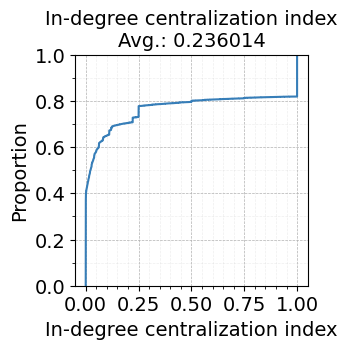

In [22]:
data = df['in_cent']
avg_in_cent = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('In-degree centralization index\nAvg.: {:.6f}'.format(avg_in_cent))
ax.set_xlabel('In-degree centralization index')
sns.ecdfplot(data, color='#377eb8', ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/cent-indeg-cumul.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [12]:
# data = df['in_cent']
# step = 0.05
# max = 1.0
# avg_in_cent = data.mean()
# counts, bins = np.histogram(data, bins=np.arange(0, max+2*step, step))
# fig, ax = plt.subplots(figsize=(3, 3))
# ax.set_title('In-degree centralization index\nAvg.: {:.6f}'.format(avg_in_cent))
# ax.set_xlabel('In-degree centralization index')
# ax.set_ylabel('% of contracts')
# ax.stairs((np.cumsum(counts) * 100) / len(data), bins, fill=True, color='#377eb8')
# ax.grid(which='major', linestyle='--', linewidth=0.5)
# ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
# ax.xaxis.set_minor_locator(AutoMinorLocator(5))
# ax.yaxis.set_minor_locator(AutoMinorLocator(2))
# utils.set_font_size(ax, 14)
# plt.savefig("figures/cent-indeg-cumul.pdf", format='pdf', bbox_inches='tight')
# plt.show()

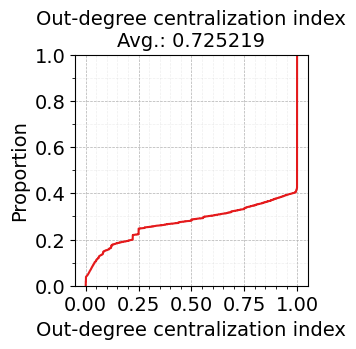

In [14]:
data = df['out_cent']
avg_out_cent = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Out-degree centralization index\nAvg.: {:.6f}'.format(avg_out_cent))
ax.set_xlabel('Out-degree centralization index')
sns.ecdfplot(data, color='#e41a1c', ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/cent-outdeg-cumul.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [13]:
# data = cdf['out_cent']
# step = 0.05
# max = 1.0
# avg_out_cent = data.mean()
# counts, bins = np.histogram(data, bins=np.arange(0, max+2*step, step))
# fig, ax = plt.subplots(figsize=(3, 3))
# ax.set_title('Out-degree centralization index\nAvg.: {:.6f}'.format(avg_out_cent))
# ax.set_xlabel('Out-degree centralization index')
# ax.set_ylabel('% of contracts')
# ax.stairs((np.cumsum(counts) * 100) / len(data), bins, fill=True, color='#e41a1c')
# ax.grid(which='major', linestyle='--', linewidth=0.5)
# ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
# ax.xaxis.set_minor_locator(AutoMinorLocator(5))
# ax.yaxis.set_minor_locator(AutoMinorLocator(2))
# utils.set_font_size(ax, 14)
# plt.savefig("figures/cent-outdeg-cumul.pdf", format='pdf', bbox_inches='tight')
# plt.show()

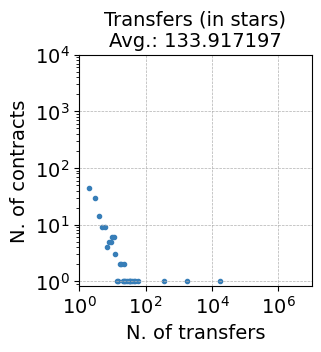

In [5]:
data = in_stars['num_transfer'].value_counts()
mean_value = in_stars['num_transfer'].mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Transfers (in stars)\nAvg.: {:.6f}'.format(mean_value))
ax.set_xlabel('N. of transfers')
ax.set_ylabel('N. of contracts')
ax.set_xscale('log')
ax.set_yscale('log')
ax.scatter(data['num_transfer'], data['count'], color='#377eb8', marker='.', rasterized=True)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.set_xticks([1, 1e2, 1e4, 1e6])
ax.set_xlim(right=1e7)
ax.set_ylim(top=1e4)
utils.set_font_size(ax, 14)
plt.savefig("figures/cent-transfers-in.pdf", format='pdf', bbox_inches='tight')
plt.show()

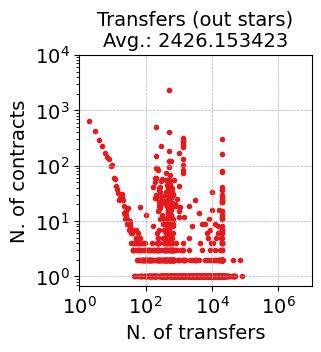

In [6]:
data = out_stars['num_transfer'].value_counts()
mean_value = out_stars['num_transfer'].mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Transfers (out stars)\nAvg.: {:.6f}'.format(mean_value))
ax.set_xlabel('N. of transfers')
ax.set_ylabel('N. of contracts')
ax.set_xscale('log')
ax.set_yscale('log')
ax.scatter(data['num_transfer'], data['count'], color='#e41a1c', marker='.', rasterized=True)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.set_xticks([1, 1e2, 1e4, 1e6])
ax.set_xlim(right=1e7)
ax.set_ylim(top=1e4)
utils.set_font_size(ax, 14)
plt.savefig("figures/cent-transfers-out.pdf", format='pdf', bbox_inches='tight')
plt.show()

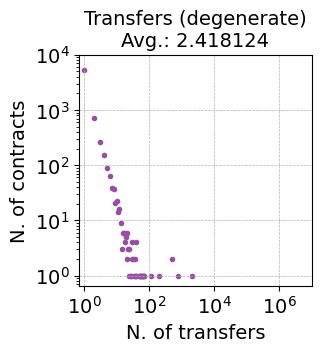

In [7]:
data = in_out_stars['num_transfer'].value_counts()
mean_value = in_out_stars['num_transfer'].mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Transfers (degenerate)\nAvg.: {:.6f}'.format(mean_value))
ax.set_xlabel('N. of transfers')
ax.set_ylabel('N. of contracts')
ax.set_xscale('log')
ax.set_yscale('log')
ax.scatter(data['num_transfer'], data['count'], color='#984ea3', marker='.', rasterized=True)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.set_xticks([1, 1e2, 1e4, 1e6])
ax.set_xlim(right=1e7)
ax.set_ylim(top=1e4)
utils.set_font_size(ax, 14)
plt.savefig("figures/cent-transfers-deg.pdf", format='pdf', bbox_inches='tight')
plt.show()

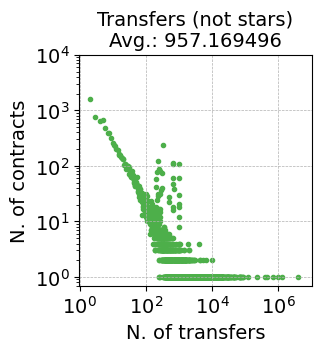

In [8]:
data = not_stars['num_transfer'].value_counts()
mean_value = not_stars['num_transfer'].mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Transfers (not stars)\nAvg.: {:.6f}'.format(mean_value))
ax.set_xlabel('N. of transfers')
ax.set_ylabel('N. of contracts')
ax.set_xscale('log')
ax.set_yscale('log')
ax.scatter(data['num_transfer'], data['count'], color='#4daf4a', marker='.', rasterized=True)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.set_xticks([1, 1e2, 1e4, 1e6])
ax.set_xlim(right=1e7)
ax.set_ylim(top=1e4)
utils.set_font_size(ax, 14)
plt.savefig("figures/cent-transfers-non.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [2]:
tmp = pl.read_parquet(TRANSFERS_FILE)
tmp = utils.filter_transfers(tmp)
tdf = tmp.explode(['token_ids', 'amounts'])
block_timestamps = tdf.select('block_number', 'block_timestamp').unique().with_columns(
    block_timestamp=pl.col('block_timestamp').str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False)
)
active_df = pl.read_csv('results/active_stars.tsv', separator='\t', has_header=True)
active_df = active_df.join(block_timestamps, on='block_number', how='left')
active_df

block_number,in_stars,out_stars,in_out_stars,not_stars,block_timestamp
i64,i64,i64,i64,i64,datetime[μs]
7156610,0,0,0,1,2019-02-01 02:20:55
7156617,0,0,0,1,2019-02-01 02:22:08
7156942,0,0,0,1,2019-02-01 03:50:58
7157546,0,0,0,1,2019-02-01 06:55:07
7157549,0,0,0,1,2019-02-01 06:55:54
…,…,…,…,…,…
21525881,157,15441,6864,16319,2024-12-31 23:58:11
21525882,157,15441,6864,16319,2024-12-31 23:58:23
21525886,157,15441,6864,16319,2024-12-31 23:59:11


in_stars
i64
0
0
0
0
0
…
22462
22462
22462


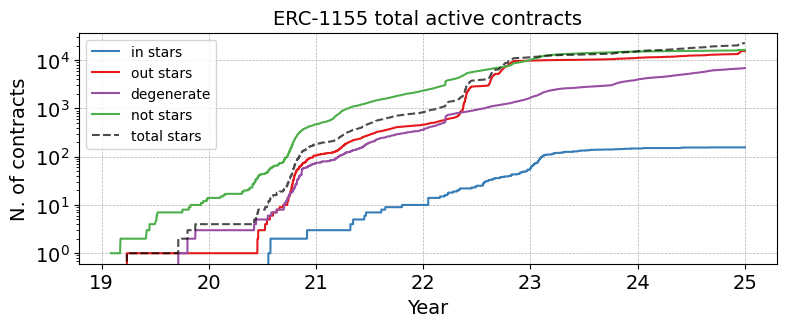

In [6]:
all_stars = active_df['in_stars'] + active_df['out_stars'] + active_df['in_out_stars']
fig, ax = plt.subplots(figsize=(9, 3))
ax.set_title('ERC-1155 total active contracts')
ax.set_xlabel('Year')
ax.set_ylabel('N. of contracts')
ax.set_yscale('log')
ax.plot(active_df['block_timestamp'], active_df['in_stars'], color='#377eb8', label='in stars')
ax.plot(active_df['block_timestamp'], active_df['out_stars'], color='#e41a1c', label='out stars')
ax.plot(active_df['block_timestamp'], active_df['in_out_stars'], color='#984ea3', label='degenerate')
ax.plot(active_df['block_timestamp'], active_df['not_stars'], color='#4daf4a', label='not stars')
ax.plot(active_df['block_timestamp'], all_stars, color='black', alpha=0.7, linestyle='--', label='total stars')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.legend(loc='upper left')
utils.set_font_size(ax, 14)
plt.savefig("figures/cent-active.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [2]:
# rank_t = not_stars.sort(by='num_transfer', descending=True)['address']
# rank_e = not_stars.sort(by='num_edges', descending=True)['address']
# max_contracts = len(not_stars)
# values = []
# for i in range(1, max_contracts+1):
#     st = set(rank_t.head(i))
#     se = set(rank_e.head(i))
#     j = len(st.intersection(se)) / len(st.union(se))
#     values.append(j)
# plt.title('Contract selection (contract transfers vs. graph edges)')
# plt.xlabel('N. of selected contracts')
# plt.ylabel('Jaccard index')
# plt.xscale('log')
# plt.plot(range(1, max_contracts+1), values)
# plt.show()

In [3]:
# rank_t = not_stars.sort(by='num_transfer', descending=True)
# total_transfers = rank_t['num_transfer'].sum()
# total_edges = rank_t['num_edges'].sum()
# #rank_e = not_stars.sort(by='num_edges', descending=True)
# max_contracts = len(not_stars)
# domain = range(1, max_contracts+1)
# t_values_t = []
# t_values_e = []
# e_values_t = []
# e_values_e = []
# for i in domain:
#     v1t = (rank_t.head(i)['num_transfer'].sum() * 100) / total_transfers
#     v2t = (rank_t.head(i)['num_edges'].sum() * 100) / total_edges
#     t_values_t.append(v1t)
#     t_values_e.append(v2t)
#     v1e = (rank_e.head(i)['num_transfer'].sum() * 100) / total_transfers
#     v2e = (rank_e.head(i)['num_edges'].sum() * 100) / total_edges
#     e_values_t.append(v1e)
#     e_values_e.append(v2e)
# plt.plot(domain, t_values_t, color='blue')
# plt.plot(domain, t_values_e, color='blue', linestyle='dotted')
# plt.plot(domain, e_values_t, color='red')
# plt.plot(domain, e_values_e, color='red', linestyle='dotted')
# plt.xscale('log')
# plt.show()

In [2]:
gdf = pl.read_csv(GRAPH_STATS_FILE, separator='\t')
gdf

contract_id,num_nodes,num_edges,coverage_wcc,coverage_scc,clustering,density,reciprocity,distance,diameter
i64,i64,i64,f64,f64,f64,f64,f64,f64,i64
0,938630,2261588,0.881761,0.151734,0.006034,0.000003,0.0450613,6.947788,181
1,81542,329122,1.0,0.334956,0.004079,0.000049,0.0352088,5.788753,42
2,102458,322871,0.99595,0.330057,0.000599,0.000031,0.0585497,5.198229,62
3,90830,262459,0.986777,0.133205,0.003033,0.000032,0.0534407,4.91925,69
4,161557,248259,0.999876,0.092791,0.000384,0.00001,0.0240716,6.571702,35
…,…,…,…,…,…,…,…,…,…
33411,3,2,1.0,0.333333,0.0,0.333333,0.0,0.673009,2
33414,3,2,1.0,0.333333,0.0,0.333333,0.0,0.673009,2
33416,3,2,1.0,0.333333,0.0,0.333333,0.0,0.673009,2


In [3]:
avg_nodes = gdf['num_nodes'].mean()
avg_edges = gdf['num_edges'].mean()
print(f'Avg. nodes: {avg_nodes}\nAvg. edges: {avg_edges}')

Avg. nodes: 396.73760647098476
Avg. edges: 564.2272198051351


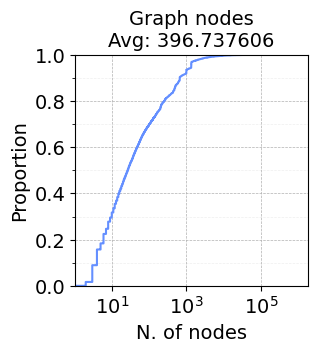

In [5]:
data = gdf['num_nodes']
avg_nodes = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Graph nodes\nAvg: {:.6f}'.format(avg_nodes))
ax.set_xlabel('N. of nodes')
sns.ecdfplot(data, log_scale=True, color='#648fff', ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.set_xticks([1e1, 1e3, 1e5])
utils.set_font_size(ax, 14)
plt.savefig("figures/graph-cumulative-nodes.pdf", format='pdf', bbox_inches='tight')
plt.show()

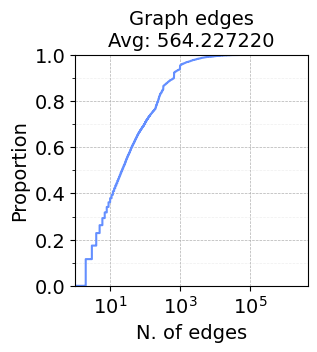

In [6]:
data = gdf['num_edges']
avg_edges = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Graph edges\nAvg: {:.6f}'.format(avg_edges))
ax.set_xlabel('N. of edges')
sns.ecdfplot(data, log_scale=True, color='#648fff', ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.set_xticks([1e1, 1e3, 1e5])
utils.set_font_size(ax, 14)
plt.savefig("figures/graph-cumulative-edges.pdf", format='pdf', bbox_inches='tight')
plt.show()

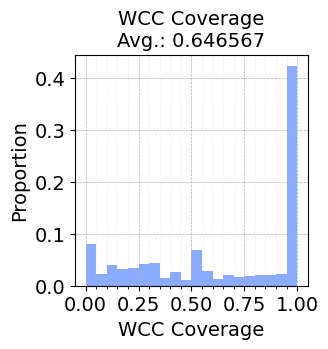

In [23]:
data = gdf['coverage_wcc']
step = 0.05
bins = np.arange(0, 1+step, step)
avg_coverage_wcc = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('WCC Coverage\nAvg.: {:.6f}'.format(avg_coverage_wcc))
ax.set_xlabel('WCC Coverage')
#sns.histplot(data, bins=bins, color='#648fff', edgecolor="none", log_scale=(False, True), ax=ax)
sns.histplot(data, bins=bins, color='#648fff', edgecolor="none", stat="proportion", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
#ax.set_yticks([1, 1e1, 1e2, 1e3, 1e4])
utils.set_font_size(ax, 14)
plt.savefig("figures/feature-dist-coverage-wcc.pdf", format='pdf', bbox_inches='tight')
plt.show()

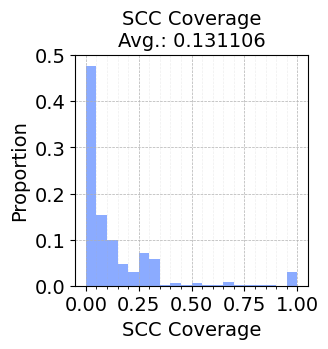

In [22]:
data = gdf['coverage_scc']
step = 0.05
bins = np.arange(0, 1+step, step)
avg_coverage_scc = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('SCC Coverage\nAvg.: {:.6f}'.format(avg_coverage_scc))
ax.set_xlabel('SCC Coverage')
#sns.histplot(data, bins=bins, color='#648fff', edgecolor="none", log_scale=(False, True), ax=ax)
sns.histplot(data, bins=bins, color='#648fff', edgecolor="none", stat="proportion", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
utils.set_font_size(ax, 14)
plt.savefig("figures/feature-dist-coverage-scc.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [8]:
num_nans = len(gdf['clustering']) - len(gdf['clustering'].drop_nans())
print(f'Clustering coefficient has {num_nans} NaN values')

Clustering coefficient has 3371 NaN values


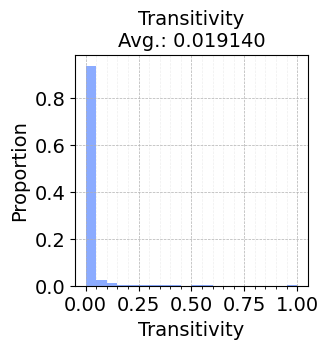

In [20]:
data = gdf['clustering'].drop_nans()
step = 0.05
bins = np.arange(0, 1+step, step)
avg_clustering = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Transitivity\nAvg.: {:.6f}'.format(avg_clustering))
ax.set_xlabel('Transitivity')
#sns.histplot(data, bins=bins, color='#648fff', edgecolor="none", log_scale=(False, True), ax=ax)
sns.histplot(data, bins=bins, color='#648fff', edgecolor="none", stat="proportion", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
utils.set_font_size(ax, 14)
plt.savefig("figures/feature-dist-transitivity.pdf", format='pdf', bbox_inches='tight')
plt.show()

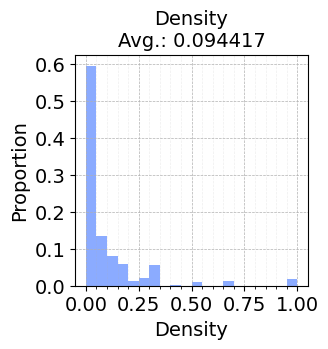

In [21]:
data = gdf['density']
step = 0.05
bins = np.arange(0, 1+step, step)
avg_density = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Density\nAvg.: {:.6f}'.format(avg_density))
ax.set_xlabel('Density')
sns.histplot(data, bins=bins, color='#648fff', edgecolor="none", stat="proportion", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
utils.set_font_size(ax, 14)
plt.savefig("figures/feature-dist-density.pdf", format='pdf', bbox_inches='tight')
plt.show()

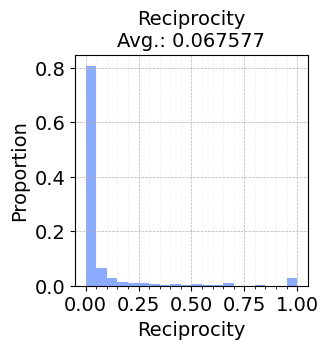

In [25]:
data = gdf['reciprocity']
step = 0.05
bins = np.arange(0, 1+step, step)
avg_reciprocity = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Reciprocity\nAvg.: {:.6f}'.format(avg_reciprocity))
ax.set_xlabel('Reciprocity')
sns.histplot(data, bins=bins, color='#648fff', edgecolor="none", stat="proportion", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
#ax.set_yticks([1, 1e1, 1e2, 1e3, 1e4])
utils.set_font_size(ax, 14)
plt.savefig("figures/feature-dist-reciprocity.pdf", format='pdf', bbox_inches='tight')
plt.show()

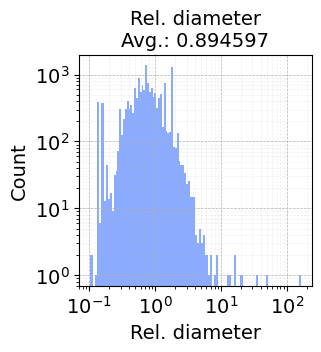

In [42]:
data = gdf['diameter'] / np.log(gdf['num_nodes'])
avg_diameter = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Rel. diameter\nAvg.: {:.6f}'.format(avg_diameter))
ax.set_xlabel('Rel. diameter')
sns.histplot(data, color='#648fff', edgecolor="none", log_scale=(True,True), ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
#ax.xaxis.set_minor_locator(AutoMinorLocator(5))
#ax.set_yticks([1, 1e1, 1e2, 1e3, 1e4])
utils.set_font_size(ax, 14)
plt.savefig("figures/feature-dist-diameter.pdf", format='pdf', bbox_inches='tight')
plt.show()

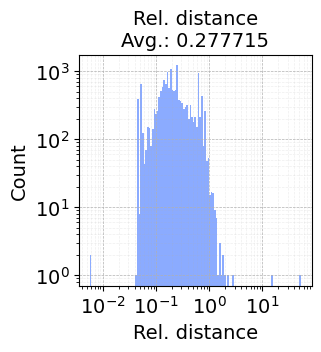

In [43]:
data = gdf['distance'] / np.log(gdf['num_nodes'])
avg_distance = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Rel. distance\nAvg.: {:.6f}'.format(avg_distance))
ax.set_xlabel('Rel. distance')
sns.histplot(data, color='#648fff', edgecolor="none", log_scale=(True,True), ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
#ax.xaxis.set_minor_locator(AutoMinorLocator(5))
#ax.set_yticks([1, 1e1, 1e2, 1e3, 1e4])
utils.set_font_size(ax, 14)
plt.savefig("figures/feature-dist-distance.pdf", format='pdf', bbox_inches='tight')
plt.show()

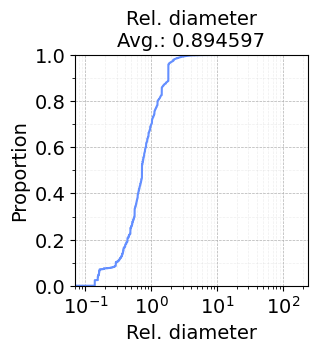

In [26]:
data = gdf['diameter'] / np.log(gdf['num_nodes'])
avg_diameter = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Rel. diameter\nAvg.: {:.6f}'.format(avg_diameter))
ax.set_xlabel('Rel. diameter')
sns.ecdfplot(data, color='#648fff', log_scale=True, ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/feature-dist-diameter-cumul.pdf", format='pdf', bbox_inches='tight')
plt.show()

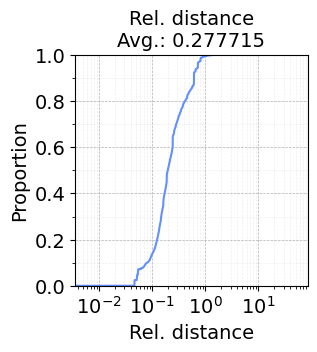

In [27]:
data = gdf['distance'] / np.log(gdf['num_nodes'])
avg_distance = data.mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Rel. distance\nAvg.: {:.6f}'.format(avg_distance))
ax.set_xlabel('Rel. distance')
sns.ecdfplot(data, color='#648fff', log_scale=True, ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/feature-dist-distance-cumul.pdf", format='pdf', bbox_inches='tight')
plt.show()